# High Garden Coffee · Analítica y pronósticos de consumo

**Objetivo:** entender el consumo y proyectar su evolución a 1, 5 y 10 años por país.

1. **Datos** · 2. **Estadísticas generales** · 3. **Análisis avanzado** · 4. **Interpretación**

Se conservan los valores originales. Los ceros representan periodos sin consumo, según lo acordado. Usamos **unidades reportadas** porque el Parquet no especifica la unidad.

## 1. Datos
### 1.1. Carga y entorno
Ejecuta las celdas en orden. Las tablas y gráficas se guardan en `resultados/`.

In [1]:
# Cargar librerías, configurar gráficos y leer el archivo original.
from pathlib import Path
import hashlib, importlib.metadata, json, platform, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

BASE = Path.cwd()
if not (BASE / 'coffee_db.parquet').exists():
    BASE = BASE / 'Prueba Tecnica MLEng'
DATA = BASE / 'coffee_db.parquet'
assert DATA.exists(), 'Ejecuta desde la carpeta del notebook o su carpeta padre.'
OUT = BASE / 'resultados'
FIG = OUT / 'figuras'
FIG.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', 16)
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
sns.set_theme(style='whitegrid', palette='colorblind', context='notebook')
plt.rcParams.update({'figure.figsize': (11, 5), 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.dpi': 110})

def guardar_figura(nombre):
    plt.tight_layout()
    plt.savefig(FIG / f'{nombre}.png', dpi=160, bbox_inches='tight')
    plt.show()
    plt.close()

versiones = {p: importlib.metadata.version(p) for p in
             ['pandas', 'pyarrow', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'statsmodels']}
manifest = {'sha256_dataset': hashlib.sha256(DATA.read_bytes()).hexdigest(),
            'python': platform.python_version(), 'paquetes': versiones}
(OUT / 'manifest.json').write_text(json.dumps(manifest, indent=2), encoding='utf-8')
raw = pd.read_parquet(DATA)
print(f'Archivo cargado: {raw.shape[0]} países × {raw.shape[1]} columnas')


Archivo cargado: 55 países × 33 columnas


### 1.2. Estructura del dataset
| Campo | Significado |
|---|---|
| `Country` | País. |
| `Coffee type` | Etiqueta del país; no separa consumo por variedad. |
| `1990/91`–`2019/20` | Consumo anual. |
| `Total_domestic_consumption` | Suma histórica; no se usa para predecir. |

In [2]:
# Seleccionar las columnas anuales y mostrar una muestra.
periodos = sorted(c for c in raw.columns if re.fullmatch(r'\d{4}/\d{2}', str(c)))
display(raw[['Country', 'Coffee type', periodos[0], periodos[-1]]].head(3))

,Country,Coffee type,1990/91,2019/20
0,Angola,Robusta/Arabica,1200000,1800000
1,Bolivia (Plurinational State of),Arabica,1500000,3660000
2,Brazil,Arabica/Robusta,492000000,1320000000


### 1.3. Organización para el análisis
Una fila por país-periodo, sin cambiar el consumo. Las etiquetas combinadas se agrupan como `Mixto`; se conserva la original.

In [3]:
# Pasar de columnas por año a filas país-periodo.
long = raw.melt(id_vars=['Country', 'Coffee type'], value_vars=periodos,
                var_name='periodo', value_name='consumo').rename(
                    columns={'Country': 'pais', 'Coffee type': 'tipo_cafe_original'})
long['anio'] = long['periodo'].str[:4].astype(int)
long['grupo_cafe'] = long.tipo_cafe_original.replace({
    'Arabica/Robusta': 'Mixto', 'Robusta/Arabica': 'Mixto'})
long = long.sort_values(['pais', 'anio']).reset_index(drop=True)
long.to_parquet(OUT / 'consumo_formato_largo.parquet', index=False)
print(f'{long.pais.nunique()} países · {len(periodos)} periodos · {len(long):,} observaciones país-periodo')

55 países · 30 periodos · 1,650 observaciones país-periodo


## 2. Estadísticas generales
### 2.1. Países por etiqueta
Cantidad de países; no consumo por variedad.

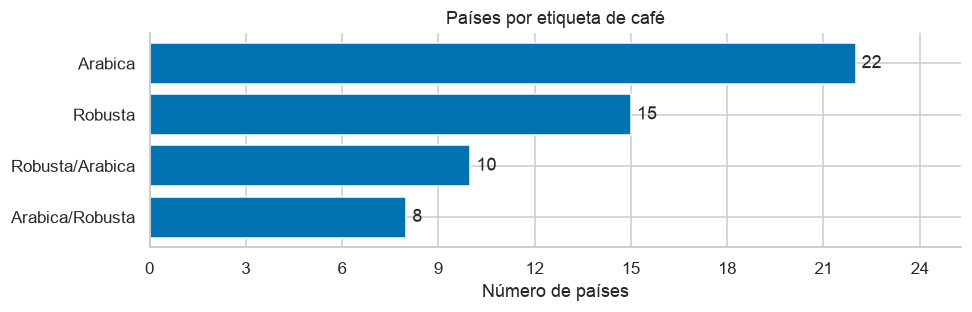

In [4]:
# Contar países por etiqueta original de café.
etiquetas = (raw.groupby('Coffee type')['Country'].nunique().sort_values()
             .rename_axis('etiqueta').reset_index(name='paises'))
etiquetas.to_csv(OUT / 'paises_por_etiqueta.csv', index=False)
fig, ax = plt.subplots(figsize=(9, 3))
barras = ax.barh(etiquetas.etiqueta, etiquetas.paises)
ax.bar_label(barras, padding=4, fmt='%d')
ax.set(xlabel='Número de países', title='Países por etiqueta de café')
ax.set_xlim(0, etiquetas.paises.max() * 1.15)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
guardar_figura('00_paises_por_etiqueta')



### 2.2. Consumo del conjunto
Suma anual de los países suministrados; no representa todo el mercado mundial.

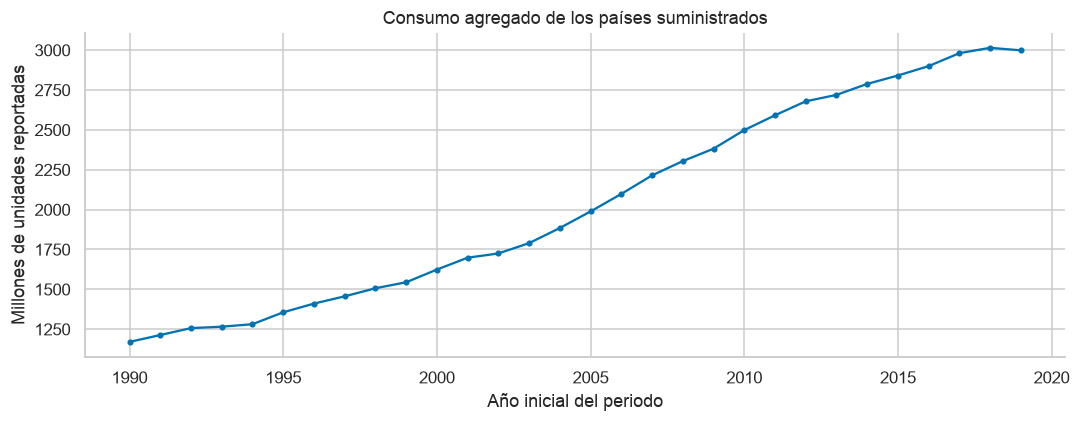

In [5]:
# Sumar el consumo de todos los países para cada año.
agregado = long.groupby('anio')['consumo'].sum()
agregado.rename('consumo').reset_index().to_csv(OUT / 'consumo_agregado.csv', index=False)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(agregado.index, agregado / 1e6, marker='o', markersize=3)
ax.set(title='Consumo agregado de los países suministrados',
       xlabel='Año inicial del periodo', ylabel='Millones de unidades reportadas')
guardar_figura('04_tendencias_agregadas')

### 2.3. Mayores mercados en 2019/20
Consumo del último periodo **anual** disponible; no implica demanda de importaciones.

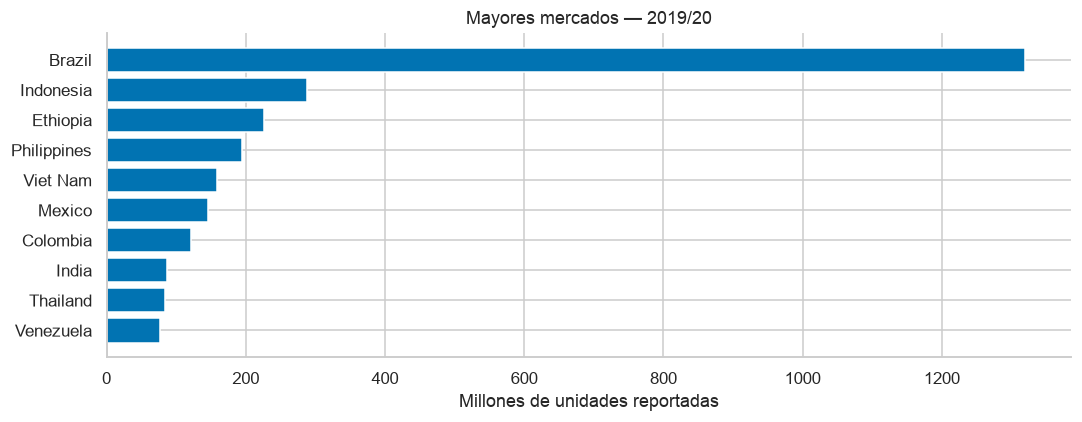

In [6]:
# Ordenar países por consumo del último periodo.
ultimo = long.anio.max()
latest = long[long.anio.eq(ultimo)].copy().sort_values('consumo', ascending=False)
latest['participacion_pct'] = 100 * latest.consumo / latest.consumo.sum()
latest[['pais', 'consumo', 'participacion_pct']].head(10).to_csv(
    OUT / 'top_mercados_ultimo_periodo.csv', index=False)
fig, ax = plt.subplots(figsize=(10, 4))
top = latest.head(10).sort_values('consumo')
ax.barh(top.pais, top.consumo / 1e6)
ax.set(xlabel='Millones de unidades reportadas', title='Mayores mercados — 2019/20')
guardar_figura('03_top_mercados')

### 2.4. Crecimiento relativo
Primer periodo = **100**. Un índice de 200 significa el doble del consumo inicial.

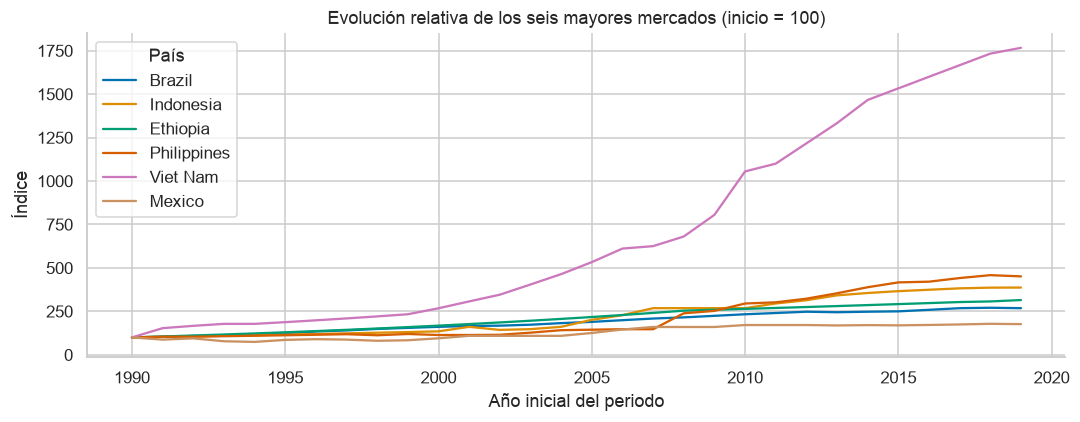

In [7]:
# Dividir cada serie por su valor inicial para comparar crecimiento.
panel = long.pivot(index='anio', columns='pais', values='consumo').sort_index()
elegidos = latest.head(6).pais.tolist()
inicial = panel.loc[panel.index.min(), elegidos].replace(0, np.nan)
indice = panel[elegidos].div(inicial) * 100
indice.to_csv(OUT / 'indice_mercados.csv', index_label='anio')
indice.plot(figsize=(10, 4)).legend(title='País')
plt.title('Evolución relativa de los seis mayores mercados (inicio = 100)')
plt.ylabel('Índice'); plt.xlabel('Año inicial del periodo')
guardar_figura('05_tendencias_normalizadas')

### 2.5. Tamaño y crecimiento
Cada punto representa un país: consumo final en el eje horizontal y CAGR de 2014/15 a 2019/20 en el vertical. Se omiten bases cero (CAGR indefinido) y consumos finales cero (eje logarítmico).

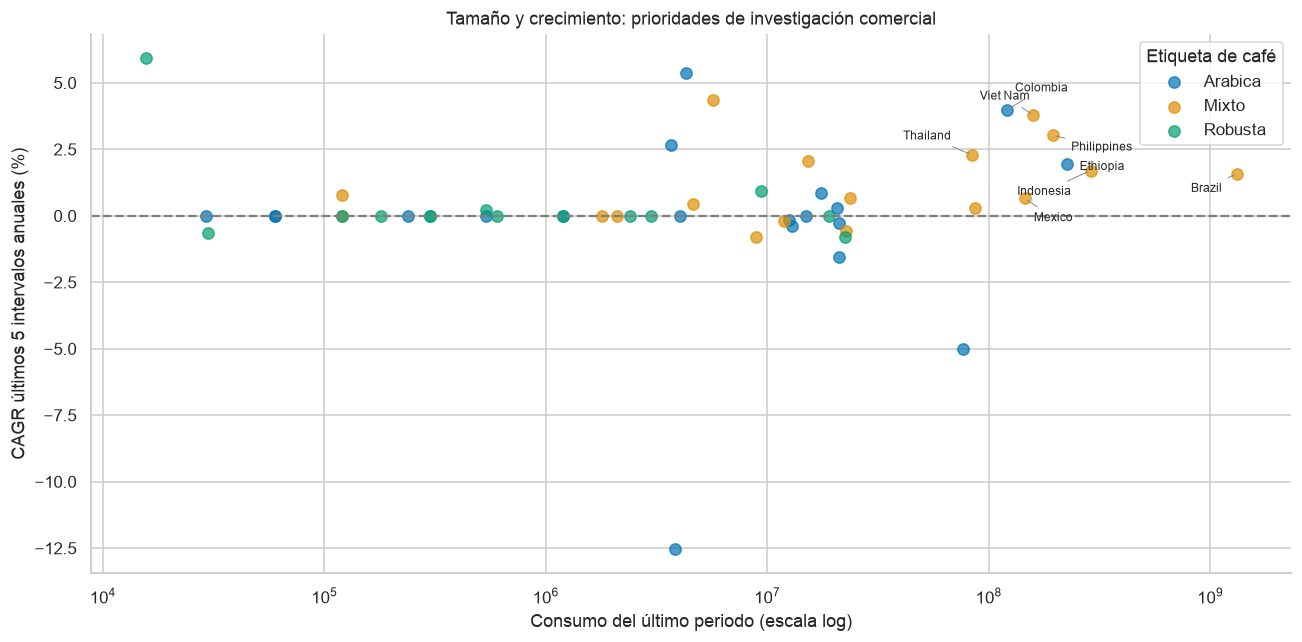

In [8]:
# Comparar el consumo final con el de cinco años antes.
consumo_final = panel.iloc[-1]
consumo_inicio5 = panel.iloc[-6]
resumen = pd.DataFrame({
    'consumo_ultimo': consumo_final,
    'cambio_absoluto_5a': consumo_final - consumo_inicio5,
    'cagr_5a_pct': 100 * ((consumo_final / consumo_inicio5.replace(0, np.nan)) ** (1/5) - 1)
}).rename_axis('pais').reset_index()
resumen = resumen.merge(long[['pais', 'grupo_cafe']].drop_duplicates(), on='pais')
resumen.to_csv(OUT / 'indicadores_paises.csv', index=False)
fig, ax = plt.subplots(figsize=(12, 6))
for grupo, g in resumen.groupby('grupo_cafe'):
    valid = g[g.consumo_ultimo.gt(0) & g.cagr_5a_pct.notna()]
    ax.scatter(valid.consumo_ultimo, valid.cagr_5a_pct, label=grupo, alpha=.7, s=55)
for _, r in resumen.nlargest(8, 'cambio_absoluto_5a').iterrows():
    if r.consumo_ultimo > 0 and pd.notna(r.cagr_5a_pct):
        desplazamientos = {'Colombia': (5, 12), 'Viet Nam': (-35, 10), 'Philippines': (12, -10),
                          'Indonesia': (-48, -16), 'Ethiopia': (8, -4),
                          'Thailand': (-45, 10), 'Mexico': (6, -15), 'Brazil': (-30, -12)}
        ax.annotate(r.pais, (r.consumo_ultimo, r.cagr_5a_pct),
                    xytext=desplazamientos.get(r.pais, (6, 6)), textcoords='offset points',
                    fontsize=8, arrowprops={'arrowstyle': '-', 'color': 'gray', 'lw': .6})
ax.set_xscale('log'); ax.axhline(0, color='gray', linestyle='--')
ax.set(xlabel='Consumo del último periodo (escala log)', ylabel='CAGR últimos 5 intervalos anuales (%)',
       title='Tamaño y crecimiento: prioridades de investigación comercial')
ax.legend(title='Etiqueta de café')
guardar_figura('06_tamano_crecimiento')


## 3. Análisis avanzado
### 3.1. Preparación y esquema temporal
Entrenamos un modelo por país. **Validación:** entrenar hasta 2004/05 y 2009/10, prediciendo cinco años en cada corte. **Prueba final:** entrenar hasta 2014/15 y predecir 2015/16–2019/20.

Los resultados de entrenamiento que se muestran son **errores en validación**, no el ajuste al mismo dato usado para entrenar. La prueba final se mantiene separada.

In [9]:
import warnings
import pyarrow.parquet as pq
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

assert len(periodos) == 30 and periodos[0] == '1990/91' and periodos[-1] == '2019/20'
assert all(int(p[-2:]) == (int(p[:4]) + 1) % 100 for p in periodos)
assert np.array_equal(panel.index, np.arange(1990, 2020))
assert not long.duplicated(['pais', 'anio']).any()
assert long.pais.notna().all() and long.tipo_cafe_original.notna().all()
assert np.isfinite(panel.to_numpy()).all() and (panel.to_numpy() >= 0).all()
unit_metadata = pq.ParquetFile(DATA).schema_arrow.metadata or {}

print('Datos listos: 55 países, 30 periodos; sin faltantes, negativos ni claves duplicadas.')

FAMILIES = ['Linear Regression', 'ETS', 'ARIMA']
CONFIGS = {'Linear Regression': ['linear'], 'ETS': ['additive', 'damped'],
           'ARIMA': ['0,0,0', '0,1,0', '1,1,0', '0,1,1']}
ORIGINS = [2004, 2009]
fit_log, forecast_cache = [], {}


# Mantener nombres de exportación y traducir solo lo que se muestra.
NOMBRES_MODELOS = {'Linear Regression':'Regresión lineal', 'ETS':'ETS', 'ARIMA':'ARIMA'}
COLUMNAS_ES = {'model_name':'Modelo','horizon':'Horizonte (años)','MAE':'MAE','RMSE':'RMSE',
    'WAPE':'WAPE (%)','MASE':'MASE','bias':'Sesgo','development_MASE':'MASE validación',
    'selected':'Seleccionado','country':'País','config':'Configuración',
    'selection_metric':'Métrica de selección','development_score':'Error validación',
    'predicted_consumption':'Consumo proyectado','projected_growth_pct':'Crecimiento (%)',
    'historical_last_consumption':'Consumo histórico final','period':'Periodo',
    'market_classification':'Evolución','eligible_MASE_countries':'Países con MASE'}
MODEL_FUNCTIONS = {}

def mostrar_tabla(tabla):
    """Traducir los encabezados sin cambiar los archivos para integración."""
    vista = tabla.copy()
    if 'model_name' in vista:
        vista['model_name'] = vista.model_name.map(NOMBRES_MODELOS)
    if 'market_classification' in vista:
        vista['market_classification'] = vista.market_classification.replace({
            'growing':'Crecimiento','stable':'Estabilidad','declining':'Disminución'})
    display(vista.rename(columns=COLUMNAS_ES))


Datos listos: 55 países, 30 periodos; sin faltantes, negativos ni claves duplicadas.


### 3.2. Funciones comunes de evaluación
**MAE:** error medio. **RMSE:** penaliza errores grandes. **WAPE:** error porcentual agregado. **MASE:** error escalado para comparar países. **Sesgo:** positivo significa sobreestimación.

Se elige la configuración con menor MASE en validación; si la historia es constante, se usa MAE y se registra. No se imputan datos ni se ocultan ajustes fallidos.

In [10]:
# Escalar solo con el entrenamiento para estabilizar los cálculos numéricos.
def forecast(country, family, config, origin, steps):
    # Reutilizar predicciones si ya se ajustó el mismo modelo y corte.
    key = (country, family, config, origin, steps)
    if key in forecast_cache:
        return forecast_cache[key]
    # El modelo nunca recibe observaciones posteriores al origen.
    y = panel.loc[panel.index <= origin, country].to_numpy(dtype=float)
    factor = max(1.0, np.mean(np.abs(y)))
    z = y / factor
    status, note, warning_text = 'ok', '', ''
    optimizer, retry_used = 'no aplica', False
    pred = np.full(steps, np.nan)
    try:
        with warnings.catch_warnings(record=True) as recorded:
            warnings.simplefilter('always')
            values, optimizer, retry_used = MODEL_FUNCTIONS[family](z, config, steps)
            warning_text = ' | '.join(sorted(set(str(w.message) for w in recorded)))
        values = np.asarray(values, dtype=float) * factor
        if not np.isfinite(values).all():
            raise ValueError('Predicción no finita')
        # Evitar consumos negativos de forma consistente.
        pred = np.maximum(values, 0.0)
        clipped = int(np.sum(values < 0))
    except Exception as exc:
        status, note, clipped = 'failed', str(exc), 0
    fit_log.append({'country': country, 'model_name': family, 'config': config,
                    'origin_year': origin, 'steps': steps, 'status': status,
                    'negative_predictions_clipped': clipped, 'message': note,
                    'warnings': warning_text, 'optimizer': optimizer, 'retry_used': retry_used})
    forecast_cache[key] = (pred, status)
    return pred, status

def metric_values(actual, predicted, scales):
    if not np.isfinite(predicted).all():
        return {k: np.nan for k in ['MAE','RMSE','WAPE','MASE','bias']}
    # Sesgo positivo: el modelo sobreestima el consumo.
    error = predicted - actual
    return {'MAE': np.mean(np.abs(error)), 'RMSE': np.sqrt(np.mean(error**2)),
            'WAPE': 100*np.sum(np.abs(error))/np.sum(actual) if np.sum(actual)>0 else np.nan,
            'MASE': np.mean(np.abs(error)/scales) if np.all(scales>0) else np.nan,
            'bias': np.mean(error)}

# Evaluar cada valor anual del horizonte, no solo el último.
def evaluate(country, family, config, origins, stage):
    rows, predictions = [], []
    for origin in origins:
        pred, status = forecast(country, family, config, origin, 5)
        actual = panel.loc[np.arange(origin+1, origin+6), country].to_numpy(dtype=float)
        scale = np.mean(np.abs(np.diff(panel.loc[panel.index<=origin, country])))
        for step, (a,p) in enumerate(zip(actual,pred), 1):
            predictions.append({'country': country, 'model_name': family, 'config': config,
                'stage': stage, 'origin_year': origin, 'step': step,
                'year': origin+step, 'actual': a, 'prediction': p,
                'training_scale': scale, 'fit_status': status})
    frame = pd.DataFrame(predictions)
    for horizon in [1,5]:
        g = frame[frame.step <= horizon]
        measures = metric_values(g.actual.to_numpy(),g.prediction.to_numpy(),g.training_scale.to_numpy())
        rows.append({'country':country,'model_name':family,'config':config,'stage':stage,
            'horizon':horizon, **measures, 'n_predictions':len(g),
            'status':'ok' if np.isfinite(g.prediction).all() else 'failed',
            'mase_status':'defined' if np.isfinite(measures['MASE']) else
                         ('fit_failed' if not np.isfinite(g.prediction).all() else 'zero_training_scale'),
            'wape_status':'defined' if np.isfinite(measures['WAPE']) else
                         ('fit_failed' if not np.isfinite(g.prediction).all() else 'zero_actual_volume')})
    return pd.DataFrame(rows), frame# Comparar los tres modelos sobre los mismos países con MASE calculable.
def common_countries(metrics):
    return [c for c in panel.columns if
            metrics[metrics.country.eq(c)].MASE.notna().sum() == len(FAMILIES)*2]

def aggregate(metrics, predictions, eligible):
    rows=[]
    for family in metrics.model_name.unique():
        for horizon in [1,5]:
            m=metrics[(metrics.model_name==family)&(metrics.horizon==horizon)]
            g=predictions[(predictions.model_name==family)&(predictions.step<=horizon)]
            valid=g[np.isfinite(g.prediction)]
            measures=metric_values(valid.actual.to_numpy(),valid.prediction.to_numpy(),
                                   valid.training_scale.to_numpy())
            mase=m[m.country.isin(eligible)].MASE.mean()
            rows.append({'model_name':family,'horizon':horizon,
                **{k:v for k,v in measures.items() if k!='MASE'}, 'MASE':mase,
                'eligible_MASE_countries':len(eligible),'successful_countries':int(m.status.eq('ok').sum()),
                'expected_countries':len(panel.columns),'n_successful_predictions':len(valid),
                'n_expected_predictions':len(g)})
    return pd.DataFrame(rows)

selection_rows, dev_metric_rows, dev_prediction_rows, config_rows = [], [], [], []

def entrenar_familia(family):
    """Elegir una configuración por país usando únicamente validación."""
    seleccion, metricas, predicciones = [], [], []
    for country in panel.columns:
        candidatos = []
        for config in CONFIGS[family]:
            m, pred = evaluate(country, family, config, ORIGINS, 'development')
            ok = m.status.eq('ok').all()
            # Cuando la historia es constante, MASE no existe: usar MAE y registrarlo.
            criterio = 'MASE' if m.MASE.notna().all() else 'MAE'
            error = m[criterio].mean() if ok else np.inf
            candidatos.append((error, config, criterio, m, pred))
            config_rows.append({'country':country,'model_name':family,'config':config,
                                'criterion':criterio,'score':error,'status':'ok' if ok else 'failed'})
        error, config, criterio, m, pred = min(candidatos, key=lambda x:x[0])
        seleccion.append({'country':country,'model_name':family,'config':config,
            'selection_metric':criterio,'development_score':error,
            'status':'ok' if np.isfinite(error) else 'failed'})
        metricas.append(m); predicciones.append(pred)
    s = pd.DataFrame(seleccion)
    m = pd.concat(metricas, ignore_index=True)
    pred = pd.concat(predicciones, ignore_index=True)
    selection_rows.extend(seleccion)
    dev_metric_rows.append(m); dev_prediction_rows.append(pred)
    elegibles = m.groupby('country').MASE.count().loc[lambda x:x.eq(2)].index.tolist()
    resultados = aggregate(m, pred, elegibles)
    print(f'{NOMBRES_MODELOS[family]}: {s.status.eq("ok").sum()}/{len(s)} países ajustados; '
          f'{len(elegibles)} países con MASE en validación.')
    mostrar_tabla(resultados[['model_name','horizon','MAE','RMSE','WAPE','MASE','bias']])
    print('Ejemplo de configuraciones elegidas por país:')
    mostrar_tabla(s[['country','config','selection_metric','development_score']].head(3))
    # Error por paso: ayuda a ver si el error crece al alejarse del origen.
    g = pred[pred.country.isin(elegibles)].copy()
    g['error_escalado'] = (g.prediction-g.actual).abs()/g.training_scale
    curva = g.groupby('step').error_escalado.mean()
    fig, ax = plt.subplots(figsize=(8,3))
    ax.plot(curva.index, curva, marker='o')
    ax.set(title=f'{NOMBRES_MODELOS[family]} — error de validación por paso',
           xlabel='Años después del origen',ylabel='Error absoluto escalado medio')
    ax.set_xticks(range(1,6))
    guardar_figura({'Linear Regression':'10_error_regresion','ETS':'11_error_ets',
                   'ARIMA':'12_error_arima'}[family])


### 3.3. Regresión lineal
Referencia sencilla: ajustar una recta al consumo usando el tiempo como única variable. No tiene configuraciones alternativas.

Regresión lineal: 55/55 países ajustados; 49 países con MASE en validación.


,Modelo,Horizonte (años),MAE,RMSE,WAPE (%),MASE,Sesgo
0,Regresión lineal,1,"3,048,831.928","8,167,169.338",7.474,2.600,"-2,594,764.041"
1,Regresión lineal,5,"4,746,508.289","12,669,314.795",10.759,4.262,"-3,854,013.625"


Ejemplo de configuraciones elegidas por país:


,País,Configuración,Métrica de selección,Error validación
0,Angola,linear,MASE,0.960
1,Bolivia (Plurinational State of),linear,MASE,0.531
2,Brazil,linear,MASE,0.851


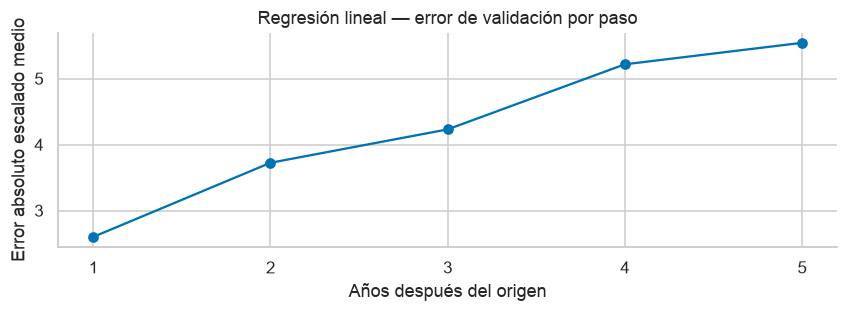

In [11]:
def predecir_regresion(y, configuracion, pasos):
    # X = posición anual; y = consumo de entrenamiento, escalado.
    tiempo = np.arange(len(y)).reshape(-1, 1)
    modelo = LinearRegression().fit(tiempo, y)
    # Continuar el índice temporal para los próximos años.
    tiempo_futuro = np.arange(len(y), len(y)+pasos).reshape(-1, 1)
    return modelo.predict(tiempo_futuro), 'no aplica', False

MODEL_FUNCTIONS['Linear Regression'] = predecir_regresion
entrenar_familia('Linear Regression')

### 3.4. Suavizamiento exponencial (ETS)
Modela nivel y tendencia. Comparamos tendencia aditiva normal y amortiguada, que reduce la tendencia a largo plazo. Sin estacionalidad porque los datos son anuales.

ETS: 55/55 países ajustados; 49 países con MASE en validación.


,Modelo,Horizonte (años),MAE,RMSE,WAPE (%),MASE,Sesgo
0,ETS,1,"1,360,921.882","4,177,787.294",3.336,1.075,"-963,092.489"
1,ETS,5,"3,211,626.741","9,741,830.423",7.280,2.541,"-2,104,939.489"


Ejemplo de configuraciones elegidas por país:


,País,Configuración,Métrica de selección,Error validación
0,Angola,additive,MASE,0.960
1,Bolivia (Plurinational State of),additive,MASE,1.773
2,Brazil,additive,MASE,0.657


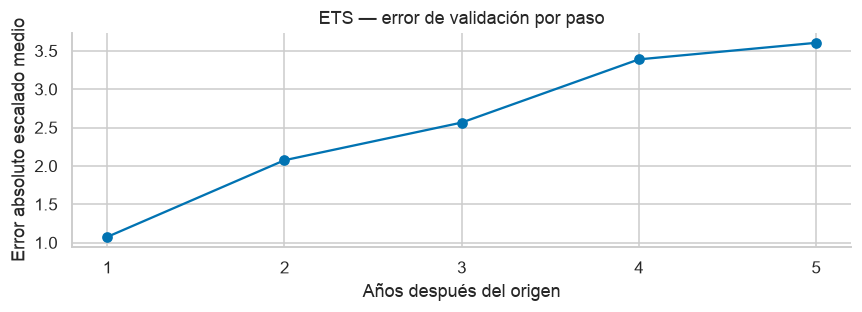

In [12]:
def predecir_ets(y, configuracion, pasos):
    # La validación decide si conviene amortiguar la tendencia.
    modelo = ExponentialSmoothing(
        y, trend='add', damped_trend=configuracion=='damped',
        seasonal=None, initialization_method='estimated'
    ).fit(optimized=True, use_brute=False)
    if not modelo.mle_retvals.success:
        raise RuntimeError('ETS no convergió')
    return modelo.forecast(pasos), 'optimización ETS', False

MODEL_FUNCTIONS['ETS'] = predecir_ets
entrenar_familia('ETS')

### 3.5. ARIMA
Combina dependencia de valores previos (**p**), diferencias (**d**) y errores previos (**q**). Evaluamos cuatro órdenes pequeños. Si el primer optimizador no converge, reintentamos el mismo modelo con Powell; no usamos la prueba para elegir parámetros.

ARIMA: 55/55 países ajustados; 49 países con MASE en validación.


,Modelo,Horizonte (años),MAE,RMSE,WAPE (%),MASE,Sesgo
0,ARIMA,1,"1,041,378.668","3,929,491.378",2.553,0.607,"-912,116.199"
1,ARIMA,5,"3,015,898.155","10,660,821.174",6.836,1.951,"-2,541,619.598"


Ejemplo de configuraciones elegidas por país:


,País,Configuración,Métrica de selección,Error validación
0,Angola,"0,1,0",MASE,0.400
1,Bolivia (Plurinational State of),"0,1,0",MASE,2.015
2,Brazil,"1,1,0",MASE,0.433


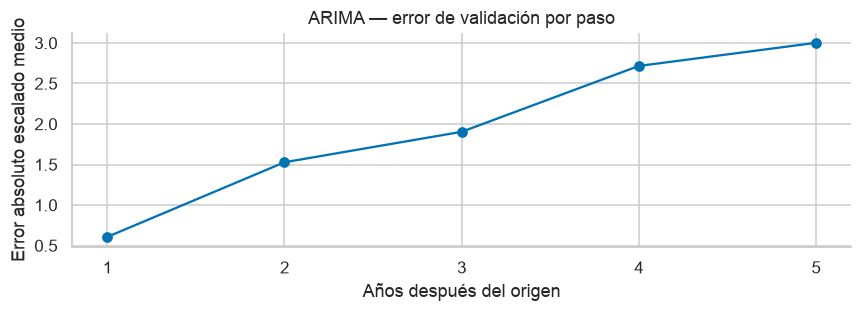

In [13]:
def predecir_arima(y, configuracion, pasos):
    orden = tuple(map(int, configuracion.split(',')))
    # Sin tendencia determinista para d=1; con constante para d=0.
    especificacion = ARIMA(y, order=orden, trend='n' if orden[1] else 'c')
    modelo = especificacion.fit(method_kwargs={'maxiter':200})
    optimizador, reintento = 'lbfgs', False
    # Cambiar solo el optimizador, conservando datos y orden (p,d,q).
    if not modelo.mle_retvals.get('converged', True):
        optimizador, reintento = 'powell', True
        modelo = especificacion.fit(method_kwargs={'method':'powell', 'maxiter':200})
    if not modelo.mle_retvals.get('converged', True):
        raise RuntimeError('ARIMA no convergió con ninguno de los optimizadores')
    return modelo.forecast(pasos), optimizador, reintento

MODEL_FUNCTIONS['ARIMA'] = predecir_arima
entrenar_familia('ARIMA')

### 3.6. Comparación y selección final
Elegimos el menor **MASE promedio de validación**, dando igual peso a países y horizontes 1 y 5, con cobertura completa. Después evaluamos la prueba final **sin cambiar el ganador**.

Un MASE de ventana de cinco años evalúa los cinco valores anuales. MASE < 1 no garantiza vencer a un naive en prueba; usa la variación del entrenamiento como referencia. Los casos indefinidos permanecen en las exportaciones.

,Modelo,Horizonte (años),MASE validación,MASE,MAE,RMSE,WAPE (%),Sesgo,Seleccionado
0,Regresión lineal,1,2.600,4.171,"4,683,491.586","11,754,318.667",9.067,"-1,046,529.774",False
1,Regresión lineal,5,4.262,5.349,"5,215,535.941","12,839,868.549",9.733,"-387,745.947",False
2,ETS,1,1.075,0.995,"873,467.268","2,946,309.430",1.691,"594,434.035",False
3,ETS,5,2.541,2.087,"1,964,482.830","5,909,570.762",3.666,"1,784,496.368",False
4,ARIMA,1,0.607,1.316,"709,672.587","1,800,061.265",1.374,"-387,441.205",True
5,ARIMA,5,1.951,2.177,"2,139,468.552","8,146,796.316",3.993,"-1,619,979.440",True


Modelo elegido: ARIMA. Países con MASE: 49 en validación y 52 en prueba.


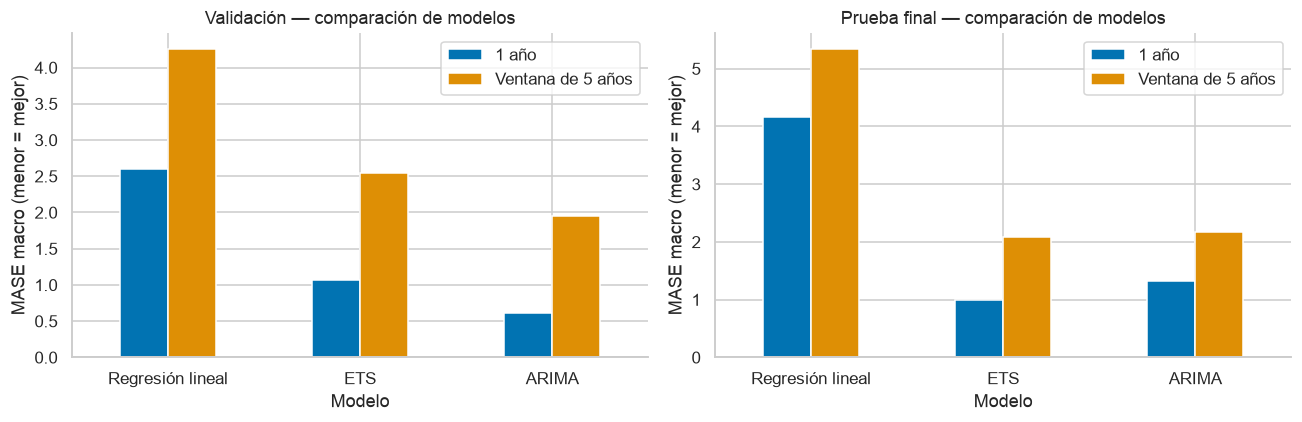

In [14]:
# Reunir los resultados de los tres bloques anteriores.
selected_configs = pd.DataFrame(selection_rows)
dev_metrics = pd.concat(dev_metric_rows, ignore_index=True)
dev_predictions = pd.concat(dev_prediction_rows, ignore_index=True)

dev_eligible=common_countries(dev_metrics)
assert dev_eligible, 'No hay países comunes con MASE calculable.'
dev_aggregate=aggregate(dev_metrics,dev_predictions,dev_eligible)
scores=dev_aggregate.groupby('model_name').MASE.mean().reindex(FAMILIES)
coverage=selected_configs.groupby('model_name').status.apply(lambda s:s.eq('ok').all())
eligible_scores=scores[coverage.reindex(scores.index)]
assert eligible_scores.notna().any(), 'Ningún modelo tiene cobertura completa.'
WINNER=eligible_scores.idxmin()  # Elegido antes de evaluar la prueba final.

test_metric_rows, test_prediction_rows = [], []
for r in selected_configs.itertuples():
    metrics,predictions=evaluate(r.country,r.model_name,r.config,[2014],'test')
    test_metric_rows.append(metrics); test_prediction_rows.append(predictions)
test_metrics=pd.concat(test_metric_rows,ignore_index=True)
test_predictions=pd.concat(test_prediction_rows,ignore_index=True)
test_eligible=common_countries(test_metrics)
test_aggregate=aggregate(test_metrics,test_predictions,test_eligible)
comparison=dev_aggregate[['model_name','horizon','MASE','eligible_MASE_countries']].rename(
    columns={'MASE':'development_MASE','eligible_MASE_countries':'development_MASE_countries'}).merge(
    test_aggregate,on=['model_name','horizon'])
comparison['development_full_coverage']=comparison.model_name.map(coverage)
comparison['selected']=comparison.model_name.eq(WINNER)
mostrar_tabla(comparison[['model_name','horizon','development_MASE','MASE','MAE','RMSE','WAPE','bias','selected']])
print(f'Modelo elegido: {NOMBRES_MODELOS[WINNER]}. Países con MASE: '
      f'{len(dev_eligible)} en validación y {len(test_eligible)} en prueba.')

comparison.to_csv(OUT/'model_comparison.csv',index=False)
all_metrics=pd.concat([dev_metrics,test_metrics],ignore_index=True)
all_metrics['selected_model']=all_metrics.model_name.eq(WINNER)
all_metrics['evaluation_limitation']=all_metrics.stage.map({
    'development':'configuration and family selection scores; not an unbiased final estimate',
    'test':'fixed 2014/15 origin; only 1- and 5-year horizons; no 10-year validation'})
all_metrics['WAPE_unit']='percent'
all_metrics['error_unit']='reported units (unverified)'
all_metrics.to_csv(OUT/'model_evaluation.csv',index=False)
selected_configs.to_csv(OUT/'selected_configurations.csv',index=False)
pd.DataFrame(config_rows).to_csv(OUT/'configuration_evaluation.csv',index=False)
pd.concat([dev_predictions,test_predictions]).to_csv(OUT/'backtest_predictions.csv',index=False)

fig, axes = plt.subplots(1,2,figsize=(12,4))
for ax, datos, etapa in [(axes[0],dev_aggregate,'Validación'),(axes[1],test_aggregate,'Prueba final')]:
    grafica=datos.pivot(index='model_name',columns='horizon',values='MASE').reindex(FAMILIES)
    grafica.index=grafica.index.map(NOMBRES_MODELOS)
    grafica.columns=['1 año','Ventana de 5 años']
    grafica.plot(kind='bar',ax=ax,rot=0)
    ax.set(title=f'{etapa} — comparación de modelos',xlabel='Modelo',ylabel='MASE macro (menor = mejor)')
guardar_figura('07_model_comparison')


### 3.7. Proyecciones anuales: del año 1 al año 10
Reajustamos con el histórico hasta 2019/20 y proyectamos **2020/21–2029/30**. No son pronósticos actuales; el horizonte de diez años es exploratorio y no está validado.

Crecimiento compara cada consumo anual proyectado con el último observado. Clasificación: >5% crecimiento, <−5% disminución y el resto estabilidad. No equivale a significancia estadística. Con base cero, el porcentaje queda indefinido.

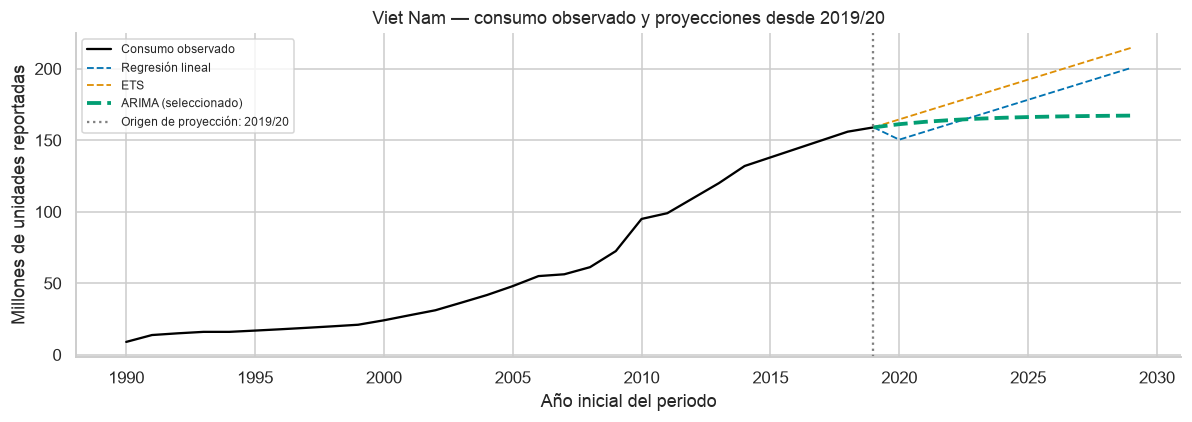

In [15]:
# Reajustar cada modelo con los 30 años; exportar las proyecciones del ganador.
coffee=raw.set_index('Country')['Coffee type']
future_rows, final_predictions = [], {}
for r in selected_configs.itertuples():
    pred,status=forecast(r.country,r.model_name,r.config,2019,10)
    final_predictions[(r.country,r.model_name)]=(pred,status)
    if r.model_name != WINNER:
        continue
    last=float(panel[r.country].iloc[-1])
    for step,value in enumerate(pred,1):
        growth=100*(value/last-1) if last>0 and np.isfinite(value) else np.nan
        category = ('unavailable' if not np.isfinite(value) else
                    ('growing' if value>0 else 'stable') if last==0 else
                    'growing' if growth>5 else 'declining' if growth<-5 else 'stable')
        future_rows.append({'country':r.country,'coffee_type':coffee.loc[r.country],
            'period':f'{2019+step}/{str(2020+step)[-2:]}','horizon':step,
            'historical_last_consumption':last,'predicted_consumption':value,
            'projected_growth_absolute':value-last,'projected_growth_pct':growth,
            'market_classification':category,'model_name':WINNER,'model_config':r.config,
            'forecast_origin':'2019/20','observed_data_end':'2019/20','data_last_updated':None,
            'measurement_unit':'reported units (unverified)','forecast_status':status,
            'projection_type':'historical-origin projection',
            'evaluation_limitation':'1- and 5-year evaluation only; 10-year horizon unvalidated'})
forecasts=pd.DataFrame(future_rows)
forecasts.to_csv(OUT/'country_forecasts.csv',index=False)
forecasts.to_parquet(OUT/'country_forecasts.parquet',index=False)
pd.DataFrame(fit_log).to_csv(OUT/'fit_diagnostics.csv',index=False)
failed_final=forecasts.loc[forecasts.forecast_status.ne('ok'),'country'].unique()
assert len(failed_final)==0, f'Falló el ajuste final en {list(failed_final)}; no se sustituyó por otro modelo.'
snapshots=forecasts[forecasts.horizon.isin([1,5,10])]
snapshots.to_csv(OUT/'forecast_horizons_1_5_10.csv',index=False)


COUNTRY_TO_PLOT='Viet Nam'
fig,ax=plt.subplots(figsize=(11,4))
ax.plot(panel.index,panel[COUNTRY_TO_PLOT]/1e6,color='black',label='Consumo observado')
for family in FAMILIES:
    pred,status=final_predictions[(COUNTRY_TO_PLOT,family)]
    if status=='ok':
        ax.plot(np.arange(2019,2030),np.r_[panel[COUNTRY_TO_PLOT].iloc[-1],pred]/1e6,
                linestyle='--',linewidth=2.5 if family==WINNER else 1.2,
                label=NOMBRES_MODELOS[family]+(' (seleccionado)' if family==WINNER else ''))
ax.axvline(2019,color='gray',linestyle=':',label='Origen de proyección: 2019/20')
ax.set(title=f'{COUNTRY_TO_PLOT} — consumo observado y proyecciones desde 2019/20',
       xlabel='Año inicial del periodo',ylabel='Millones de unidades reportadas')
ax.legend(fontsize=8)
guardar_figura('08_history_vs_forecast')

#### 3.7.1. Trayectoria año a año
La tabla muestra los **diez periodos consecutivos** del país seleccionado en `COUNTRY_TO_PLOT`. Comparamos cada año tanto con 2019/20 como con el año anterior de la trayectoria.

Todas las proyecciones salen del mismo ajuste con datos hasta 2019/20. Una actualización real del modelo necesitaría incorporar el consumo observado del nuevo año.

In [16]:
# Ordenar las proyecciones y calcular el cambio entre años consecutivos.
annual_forecasts = forecasts.sort_values(['country','horizon']).copy()
anterior = annual_forecasts.groupby('country').predicted_consumption.shift(1)
anterior = anterior.where(annual_forecasts.horizon.ne(1), annual_forecasts.historical_last_consumption)
annual_forecasts['projected_yoy_growth_pct'] = 100 * (
    annual_forecasts.predicted_consumption / anterior.replace(0, np.nan) - 1)
annual_forecasts.to_csv(OUT / 'country_forecasts_annual.csv', index=False)
# Matriz completa: una fila por país y una columna por periodo proyectado.
annual_forecasts.pivot(index='country',columns='period',values='predicted_consumption').to_csv(
    OUT / 'country_forecasts_annual_matrix.csv')

trayectoria = annual_forecasts[annual_forecasts.country.eq(COUNTRY_TO_PLOT)].copy()
tabla_anual = pd.DataFrame({
    'Año de proyección': trayectoria.horizon,
    'Periodo': trayectoria.period,
    'Consumo proyectado (millones)': trayectoria.predicted_consumption / 1e6,
    'Cambio frente a 2019/20 (%)': trayectoria.projected_growth_pct,
    'Cambio frente al año anterior (%)': trayectoria.projected_yoy_growth_pct,
})
print(f'Trayectoria anual de {COUNTRY_TO_PLOT} — modelo: {NOMBRES_MODELOS[WINNER]}')
display(tabla_anual.reset_index(drop=True))

Trayectoria anual de Viet Nam — modelo: ARIMA


,Año de proyección,Periodo,Consumo proyectado (millones),Cambio frente a 2019/20 (%),Cambio frente al año anterior (%)
0,1,2020/21,161.229,1.402,1.402
1,2,2021/22,162.886,2.444,1.028
2,3,2022/23,164.118,3.219,0.756
3,4,2023/24,165.033,3.794,0.558
4,5,2024/25,165.713,4.222,0.412
5,6,2025/26,166.218,4.540,0.305
6,7,2026/27,166.593,4.776,0.226
7,8,2027/28,166.872,4.951,0.168
8,9,2028/29,167.080,5.082,0.124
9,10,2029/30,167.234,5.179,0.092


#### 3.7.2. Ventanas de 1, 5 y 10 años
Cada panel muestra el modelo seleccionado con **todos los años de su ventana**, junto con los tres últimos periodos observados. La línea punteada marca el cierre 2019/20. La ventana de diez años es exploratoria.

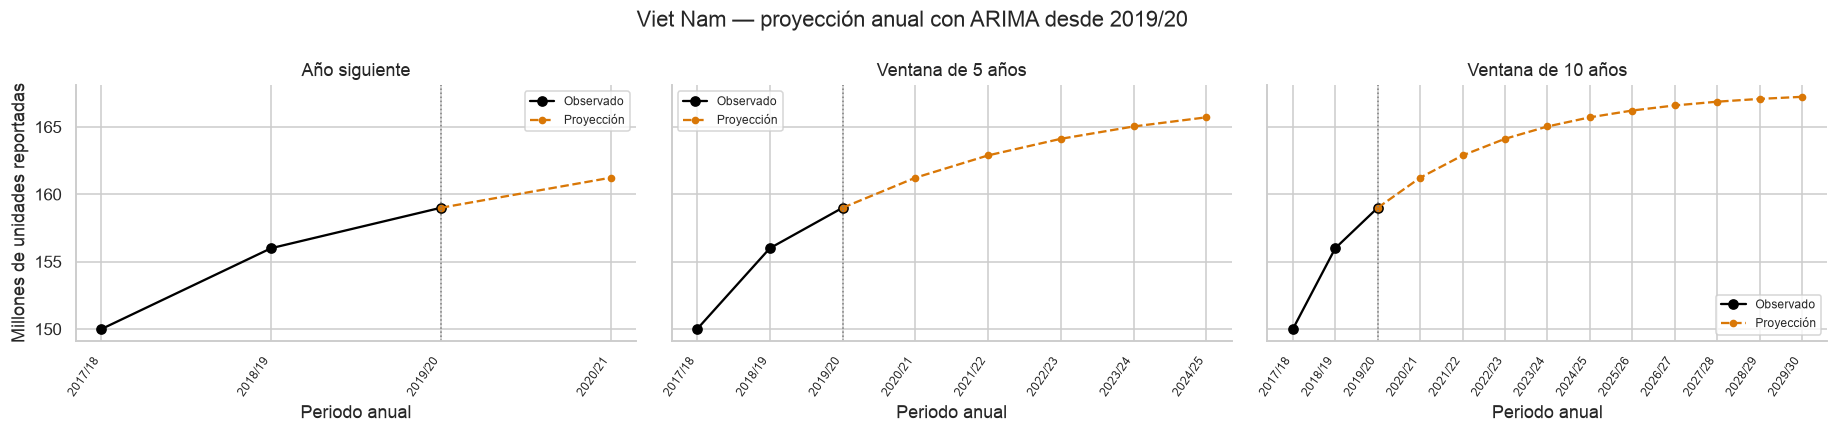

In [17]:
# Mostrar la misma trayectoria con tres ventanas; no volver a entrenar.
fig, axes = plt.subplots(1, 3, figsize=(17, 4), sharey=True)
historico = panel[COUNTRY_TO_PLOT].iloc[-3:]
ultimo_consumo = historico.iloc[-1]
for ax, ventana in zip(axes, [1, 5, 10]):
    proy = trayectoria[trayectoria.horizon.le(ventana)]
    ax.plot(historico.index, historico / 1e6, color='black', marker='o', label='Observado')
    ax.plot(np.r_[2019, 2019 + proy.horizon.to_numpy()],
            np.r_[ultimo_consumo, proy.predicted_consumption.to_numpy()] / 1e6,
            color='#d97706', linestyle='--', marker='o', markersize=4, label='Proyección')
    ax.axvline(2019, color='gray', linestyle=':', linewidth=1)
    ax.set_title('Año siguiente' if ventana == 1 else f'Ventana de {ventana} años')
    anios = np.arange(2017, 2020 + ventana)
    ax.set_xticks(anios)
    ax.set_xticklabels([f'{a}/{str(a+1)[-2:]}' for a in anios], rotation=55, ha='right', fontsize=8)
    ax.set_xlabel('Periodo anual')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Millones de unidades reportadas')
fig.suptitle(f'{COUNTRY_TO_PLOT} — proyección anual con {NOMBRES_MODELOS[WINNER]} desde 2019/20')
guardar_figura('13_proyeccion_ventanas_anuales')

### 3.8. Mercados con crecimiento proyectado
Ranking absoluto a cinco años. Para el porcentual exigimos un consumo inicial positivo y al menos igual a la mediana del último periodo. Es un filtro exploratorio, no una recomendación comercial.

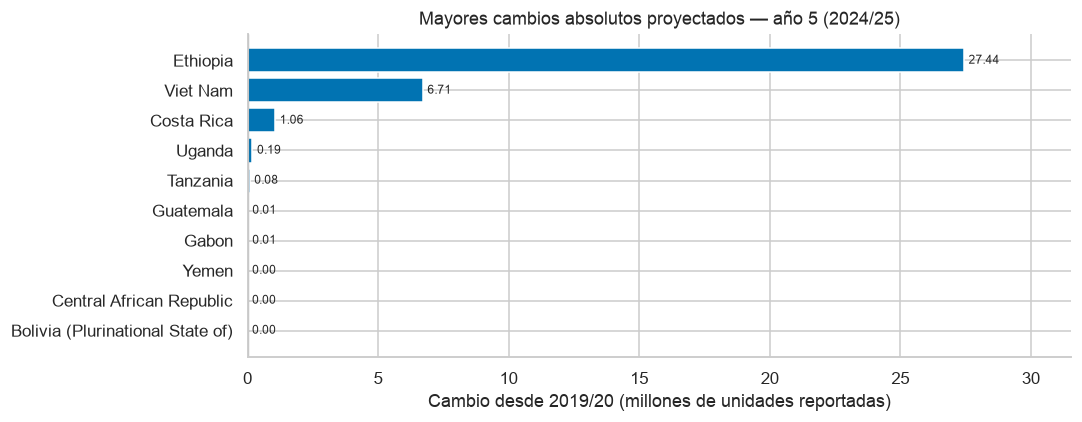

Consumo mínimo para ranking porcentual: 4,290,000 unidades (mediana del último periodo).


,País,Consumo histórico final,Consumo proyectado,Crecimiento (%)
164,Ethiopia,"226,860,000.000","254,296,633.393",12.094
84,Costa Rica,"21,120,000.000","22,177,733.595",5.008
514,Viet Nam,"159,000,000.000","165,712,513.952",4.222
444,Tanzania,"5,700,000.000","5,784,500.416",1.482
494,Uganda,"15,240,000.000","15,430,263.621",1.248


0,00 millones indica un cambio mínimo a esta escala; la clasificación usa el umbral de ±5%.


In [18]:
# Separar crecimiento absoluto de porcentual y evitar bases muy pequeñas.
MIN_BASE=float(panel.iloc[-1].median())
rankings=snapshots[snapshots.horizon.isin([5,10])].copy()
rankings['absolute_growth_rank']=rankings.groupby('horizon').projected_growth_absolute.rank(
    method='min',ascending=False)
rankings['percentage_ranking_eligible']=(rankings.historical_last_consumption>=MIN_BASE)&(
    rankings.historical_last_consumption>0)
rankings['percentage_growth_rank']=rankings[rankings.percentage_ranking_eligible].groupby(
    'horizon').projected_growth_pct.rank(method='min',ascending=False)
rankings.to_csv(OUT/'growth_opportunities.csv',index=False)
five=rankings[rankings.horizon.eq(5)]
top_abs=five.nlargest(10,'projected_growth_absolute').sort_values('projected_growth_absolute')
fig,ax=plt.subplots(figsize=(10,4))
bars=ax.barh(top_abs.country,top_abs.projected_growth_absolute/1e6)
ax.bar_label(bars,labels=[f'{v:.2f}' for v in top_abs.projected_growth_absolute/1e6],padding=3,fontsize=8)
ax.set_xlim(right=max(1,top_abs.projected_growth_absolute.max()/1e6)*1.15)
ax.axvline(0,color='gray',linewidth=.8)
ax.set(title='Mayores cambios absolutos proyectados — año 5 (2024/25)',
       xlabel='Cambio desde 2019/20 (millones de unidades reportadas)')
guardar_figura('09_growth_opportunities')
print(f'Consumo mínimo para ranking porcentual: {MIN_BASE:,.0f} unidades (mediana del último periodo).')
top_pct=five[five.percentage_ranking_eligible].nlargest(5,'projected_growth_pct')
mostrar_tabla(top_pct[['country','historical_last_consumption','predicted_consumption','projected_growth_pct']])
print('0,00 millones indica un cambio mínimo a esta escala; la clasificación usa el umbral de ±5%.')

### 3.9. Exportaciones y alcance
Guardamos histórico, proyecciones, métricas y diagnósticos para futuras consultas de un agente. Los nombres de columnas de exportación se mantienen por compatibilidad.

Sin precios históricos no se estiman precios, ventas ni rentabilidad. La fecha de actualización de la fuente es desconocida; se exporta como nula.

## 4. Interpretación de resultados
### 4.1. Hallazgos calculados
Separar observaciones históricas, desempeño en prueba y proyecciones.

In [19]:
historical_top=latest.head(3)
winning_test=test_aggregate[test_aggregate.model_name.eq(WINNER)].sort_values('horizon')
country_winners=(dev_metrics[dev_metrics.country.isin(dev_eligible)].groupby(
    ['country','model_name']).MASE.mean().unstack().reindex(columns=FAMILIES).idxmin(axis=1))
counts=country_winners.value_counts().to_dict()
top5=five.nlargest(3,'projected_growth_absolute')
ten=rankings[rankings.horizon.eq(10)].nlargest(3,'projected_growth_absolute')
classifications=rankings.groupby(['horizon','market_classification']).size().unstack(fill_value=0)
display(classifications.rename(columns={'growing':'Crecimiento','stable':'Estabilidad','declining':'Disminución'}).rename_axis('Horizonte (años)'))
test_best=test_aggregate.groupby('model_name').MASE.mean().idxmin()
summary=f"""
- **Histórico:** el consumo del conjunto aumentó **{100*(agregado.iloc[-1]/agregado.iloc[0]-1):.1f}%**. **{', '.join(historical_top.pais)}** concentran **{historical_top.participacion_pct.sum():.1f}%** del último periodo.
- **Selección:** **{NOMBRES_MODELOS[WINNER]}** ganó por MASE en validación sobre **{len(dev_eligible)} países**. Mejores modelos por país: **{ {NOMBRES_MODELOS[k]:v for k,v in counts.items()} }**.
- **Prueba del ganador:** MASE **{winning_test.iloc[0].MASE:.3f}** a un año y **{winning_test.iloc[1].MASE:.3f}** en la ventana de cinco años; WAPE **{winning_test.iloc[0].WAPE:.2f}%** y **{winning_test.iloc[1].WAPE:.2f}%**, respectivamente.
- **Comparación:** **{NOMBRES_MODELOS[test_best]}** obtuvo menor MASE promedio en prueba. No se cambia el ganador usando esos resultados.
- **Crecimiento absoluto proyectado:** a cinco años, **{', '.join(top5.country)}**; a diez, **{', '.join(ten.country)}**. Son mercados para investigar, no oportunidades demostradas.
"""
display(Markdown(summary))
(OUT/'hallazgos.md').write_text(summary,encoding='utf-8')
selection_info={'selected_model':WINNER,'selection_metric':'development macro MASE',
    'weighting':'equal eligible country and equal horizons 1 and 5; common support across families',
    'development_origins':['2004/05','2009/10'],'holdout':'2015/16–2019/20',
    'development_eligible_countries':dev_eligible,'test_eligible_countries':test_eligible,
    'forecast_origin':'2019/20','data_last_updated':None,'measurement_unit':'reported units (unverified)',
    'dataset_sha256':manifest['sha256_dataset'],'percentage_ranking_minimum_base':MIN_BASE,
    'classification_rule':'growth >5%: growing; <-5%: declining; otherwise stable',
    'negative_forecast_policy':'clip at zero before evaluation and export',
    'limitations':['10-year horizon unvalidated','no calibrated uncertainty intervals',
                   'historical-origin projections, not current forecasts','domestic consumption is not imports or sales']}
(OUT/'forecast_metadata.json').write_text(json.dumps(selection_info,indent=2),encoding='utf-8')
# Exportar el histórico con las mismas claves que las proyecciones.
history=long[['pais','tipo_cafe_original','periodo','anio','consumo']].rename(columns={
    'pais':'country','tipo_cafe_original':'coffee_type','periodo':'period','anio':'year','consumo':'consumption'})
history.to_parquet(OUT/'country_history.parquet',index=False)

market_classification,Disminución,Crecimiento,Estabilidad
Horizonte (años),,,
5,4,3,48
10,4,4,47



- **Histórico:** el consumo del conjunto aumentó **156.2%**. **Brazil, Indonesia, Ethiopia** concentran **61.2%** del último periodo.
- **Selección:** **ARIMA** ganó por MASE en validación sobre **49 países**. Mejores modelos por país: **{'ARIMA': 39, 'ETS': 7, 'Regresión lineal': 3}**.
- **Prueba del ganador:** MASE **1.316** a un año y **2.177** en la ventana de cinco años; WAPE **1.37%** y **3.99%**, respectivamente.
- **Comparación:** **ETS** obtuvo menor MASE promedio en prueba. No se cambia el ganador usando esos resultados.
- **Crecimiento absoluto proyectado:** a cinco años, **Ethiopia, Viet Nam, Costa Rica**; a diez, **Ethiopia, Viet Nam, Costa Rica**. Son mercados para investigar, no oportunidades demostradas.


### 4.2. Límites y próximos pasos
Solo hay 30 periodos anuales por país, con tramos constantes. No se modela estacionalidad mensual ni se ofrecen intervalos calibrados. El ajuste de configuraciones usa validación; la prueba final aporta la evaluación separada.

Actualizar el histórico y contrastar crecimiento con importaciones, oferta y competencia antes de decidir una expansión. Las proyecciones desde 2019/20 no validan lo ocurrido después de ese periodo.

Referencias: [Regresión lineal](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html), [ETS](https://www.statsmodels.org/stable/generated/statsmodels.tsa.holtwinters.ExponentialSmoothing.html), [ARIMA](https://www.statsmodels.org/stable/generated/statsmodels.tsa.arima.model.ARIMA.html). Ejecución: `README_analisis.md`.